# Coalescent Effective Population Size prior.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gamma, lognorm
import seaborn as sns

Estimated popultation size for 2026-05-20 is 598 based on https://github.com/wzmli/ebola_2026/tree/main which is scraped from https://insp.cd/category/sitrep/.

In [2]:
mean_target = 600
std_target = 600

## Gamma distribution

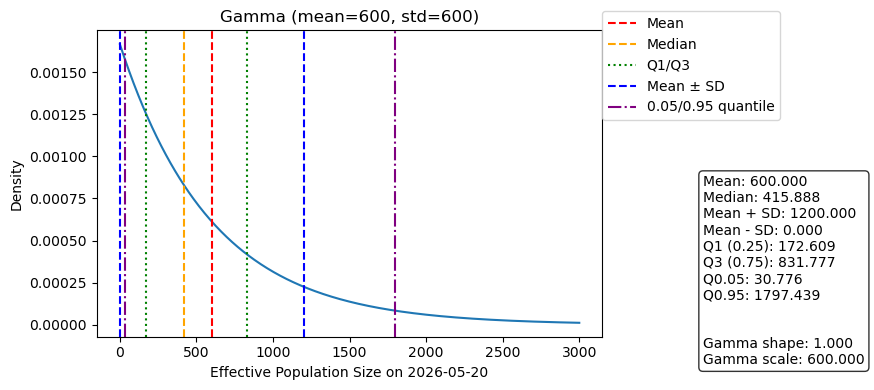

In [7]:
# Parameters for desired mean and std

shape = (mean_target / std_target) ** 2
scale = std_target ** 2 / mean_target
mu = shape * scale

x = np.linspace(0, mu + 4*scale, 500)
y = gamma.pdf(x, a=shape, scale=scale)

fig, ax = plt.subplots(figsize=(8, 4))
mean = gamma.mean(a=shape, scale=scale)
std = gamma.std(a=shape, scale=scale)
median = gamma.median(a=shape, scale=scale)
q1 = gamma.ppf(0.25, a=shape, scale=scale)
q3 = gamma.ppf(0.75, a=shape, scale=scale)
q05 = gamma.ppf(0.05, a=shape, scale=scale)
q95 = gamma.ppf(0.95, a=shape, scale=scale)

sns.lineplot(x=x, y=y, ax=ax)
ax.set_title(f"Gamma (mean={mean_target}, std={std_target})")
ax.set_xlabel("Effective Population Size on 2026-05-20")
ax.set_ylabel("Density")
ax.axvline(mean, color="red", linestyle="--", label="Mean")
ax.axvline(median, color="orange", linestyle="--", label="Median")
ax.axvline(q1, color="green", linestyle=":", label="Q1/Q3")
ax.axvline(q3, color="green", linestyle=":", label=None)
ax.axvline(mean - std, color="blue", linestyle="--", label="Mean ± SD")
ax.axvline(mean + std, color="blue", linestyle="--", label=None)
ax.axvline(q05, color="purple", linestyle="-.", label="0.05/0.95 quantile")
ax.axvline(q95, color="purple", linestyle="-.", label=None)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.885), borderaxespad=0.)

stats_text = (
    f"Mean: {mean:.3f}\n"
    f"Median: {median:.3f}\n"
    f"Mean + SD: {(mean + std):.3f}\n"
    f"Mean - SD: {(mean - std):.3f}\n"
    f"Q1 (0.25): {q1:.3f}\n"
    f"Q3 (0.75): {q3:.3f}\n"
    f"Q0.05: {q05:.3f}\n"
    f"Q0.95: {q95:.3f}\n\n\n"
    f"Gamma shape: {shape:.3f}\n"
    f"Gamma scale: {scale:.3f}"
)

fig.text(
    0.885, 0.55, stats_text,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()
fig.savefig("gamma_epop_prior_2026-05-20.png", bbox_inches="tight")

## LogNormal

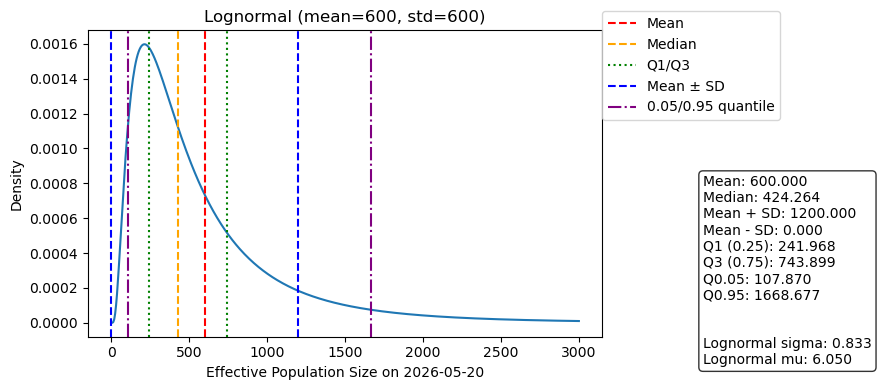

In [ ]:
# Calculate lognormal parameters
sigma = np.sqrt(np.log(1 + (std_target / mean_target) ** 2))
mu = np.log(mean_target) - 0.5 * sigma ** 2

# x range
x = np.linspace(0, mean_target + 4*std_target, 500)
y = lognorm.pdf(x, s=sigma, scale=np.exp(mu))

fig, ax = plt.subplots(figsize=(8, 4))
mean = lognorm.mean(s=sigma, scale=np.exp(mu))
std = lognorm.std(s=sigma, scale=np.exp(mu))
median = lognorm.median(s=sigma, scale=np.exp(mu))
q1 = lognorm.ppf(0.25, s=sigma, scale=np.exp(mu))
q3 = lognorm.ppf(0.75, s=sigma, scale=np.exp(mu))
q05 = lognorm.ppf(0.05, s=sigma, scale=np.exp(mu))
q95 = lognorm.ppf(0.95, s=sigma, scale=np.exp(mu))

sns.lineplot(x=x, y=y, ax=ax)
ax.set_title(f"Lognormal (mean={mean_target}, std={std_target})")
ax.set_xlabel("Effective Population Size on 2026-05-20")
ax.set_ylabel("Density")
ax.axvline(mean, color="red", linestyle="--", label="Mean")
ax.axvline(median, color="orange", linestyle="--", label="Median")
ax.axvline(q1, color="green", linestyle=":", label="Q1/Q3")
ax.axvline(q3, color="green", linestyle=":", label=None)
ax.axvline(mean - std, color="blue", linestyle="--", label="Mean ± SD")
ax.axvline(mean + std, color="blue", linestyle="--", label=None)
ax.axvline(q05, color="purple", linestyle="-.", label="0.05/0.95 quantile")
ax.axvline(q95, color="purple", linestyle="-.", label=None)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.885), borderaxespad=0.)

stats_text = (
    f"Mean: {mean:.3f}\n"
    f"Median: {median:.3f}\n"
    f"Mean + SD: {(mean + std):.3f}\n"
    f"Mean - SD: {(mean - std):.3f}\n"
    f"Q1 (0.25): {q1:.3f}\n"
    f"Q3 (0.75): {q3:.3f}\n"
    f"Q0.05: {q05:.3f}\n"
    f"Q0.95: {q95:.3f}"
    f"\n\n\nLognormal sigma: {sigma:.3f}\nLognormal mu: {mu:.3f}"
)

fig.text(
    0.885, 0.55, stats_text,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()
fig.savefig("lognormal_epop_prior_2026-05-20.png", bbox_inches="tight")

In [5]:
mu

np.float64(6.050356064936174)

In [6]:
sigma

np.float64(0.8325546111576977)